In [7]:
import os
import scanpy as sc
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score
import matplotlib.pyplot as plt

In [10]:
# --------------------------------------------------
# 1️⃣ LOAD SAVED ANNDATA
# --------------------------------------------------

adata = sc.read("/home/znazari/scRNAseq_parkinson/result/adata_scvi_leiden_sweep.h5ad")
print("Loaded:", adata.shape)

# --------------------------------------------------
# 2️⃣ VERIFY METADATA EXISTS
# --------------------------------------------------

required_cols = ["disease", "cell_type"]
missing = [c for c in required_cols if c not in adata.obs.columns]

if len(missing) > 0:
    raise ValueError(f"Missing metadata columns: {missing}")

print("Metadata already present.")

# --------------------------------------------------
# 3️⃣ CREATE celltype_condition (SAFE)
# --------------------------------------------------

adata.obs["celltype_condition"] = (
    adata.obs["cell_type"].astype(str) + "_" +
    adata.obs["disease"].astype(str)
)

# --------------------------------------------------
# 4️⃣ FIND LEIDEN COLUMNS
# --------------------------------------------------

leiden_cols = [c for c in adata.obs.columns if c.startswith("leiden")]
print("Found clustering columns:", leiden_cols)

# --------------------------------------------------
# 5️⃣ PER-CELLTYPE NMI (NO GLOBAL)
# --------------------------------------------------

output_file = "scvi_nmi_per_celltype_condition.csv"

if os.path.exists(output_file):
    nmi_df = pd.read_csv(output_file)
    print("Loaded existing results.")
else:
    nmi_df = pd.DataFrame(columns=["resolution", "celltype_condition", "NMI"])

unique_classes = adata.obs["celltype_condition"].dropna().unique()

for cluster_key in leiden_cols:

    res = float(cluster_key.replace("leiden_r", ""))

    if (nmi_df["resolution"] == res).sum() == len(unique_classes):
        print(f"Resolution {res} already done — skipping")
        continue

    print(f"Processing resolution {res}")

    valid = adata.obs[[cluster_key, "celltype_condition"]].dropna()
    clusters = valid[cluster_key].astype(str)
    labels = valid["celltype_condition"].astype(str)

    temp_results = []

    for ct in unique_classes:
        binary_label = (labels == ct).astype(int)
        nmi_ct = normalized_mutual_info_score(clusters, binary_label)

        temp_results.append({
            "resolution": res,
            "celltype_condition": ct,
            "NMI": nmi_ct
        })

    nmi_df = pd.concat([nmi_df, pd.DataFrame(temp_results)], ignore_index=True)
    nmi_df.to_csv(output_file, index=False)

print("Done.")

pivot = nmi_df.pivot(
    index="celltype_condition",
    columns="resolution",
    values="NMI"
)

sorted_pivot= pivot.sort_values(by=1.0, ascending=False)

sorted_pivot.to_csv("/home/znazari/scRNAseq_parkinson/result/nmi_table_pivot.csv", index=True)

In [22]:
sorted_pivot

resolution,0.3,0.5,0.8,1.0
celltype_condition,,,,
oligodendrocyte_Parkinson disease,0.266488,0.245871,0.221795,0.216994
glutamatergic neuron_Parkinson disease,0.196101,0.177594,0.161276,0.157369
astrocyte_Parkinson disease,0.185514,0.167489,0.149203,0.145331
GABAergic neuron_Parkinson disease,0.133507,0.120142,0.106813,0.104090
central nervous system macrophage_Parkinson disease,0.124183,0.111582,0.098946,0.096327
oligodendrocyte precursor cell_Parkinson disease,0.114710,0.102963,0.091345,0.088985
oligodendrocyte_normal,0.058228,0.055421,0.049419,0.048378
glutamatergic neuron_normal,0.056629,0.051014,0.045438,0.044277
GABAergic neuron_normal,0.036903,0.033033,0.029222,0.028442


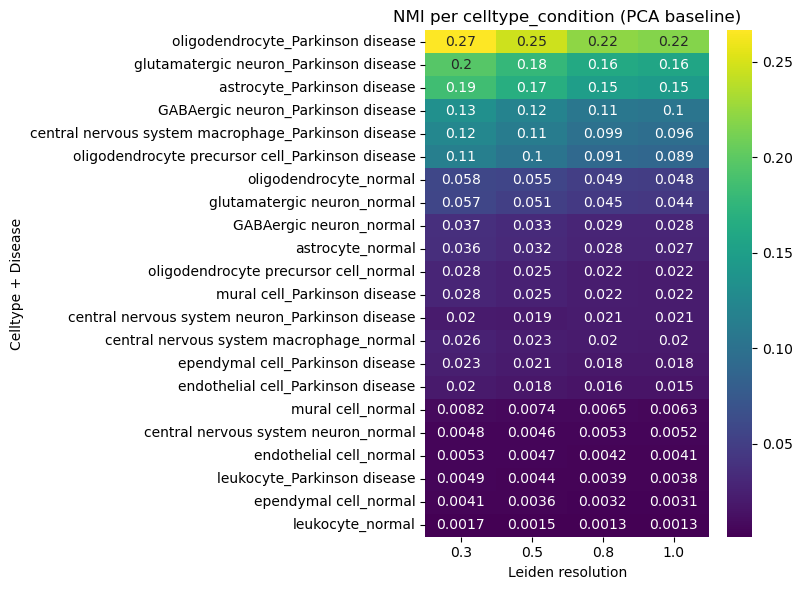

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
sorted_pivot = pd.read_csv("/home/znazari/scRNAseq_parkinson/result/nmi_table_pivot.csv", index_col=0)
plt.figure(figsize=(8,6))
sns.heatmap(sorted_pivot, annot=True, cmap="viridis")
plt.title("NMI per celltype_condition (PCA baseline)")
plt.xlabel("Leiden resolution")
plt.ylabel("Celltype + Disease")
plt.tight_layout()
plt.show()